## Partie 1 — Compréhension des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import joblib

sns.set_style("whitegrid")

In [2]:
# Lecture du fichier de ventes
donnees = pd.read_excel("data/Sales_Data.xlsx")
donnees.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Dimensions du jeu de données
donnees.shape

(541909, 8)

In [4]:
# Aperçu des types et valeurs manquantes
donnees.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


On dispose de 541 909 transactions. Deux colonnes présentent des manques : `Description` et surtout `CustomerID`. Comme l'analyse RFM se fait par client, l'identifiant client est indispensable.

## Partie 2 — Nettoyage et prétraitement

In [5]:
# Bilan des valeurs manquantes par colonne
donnees.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
# 1) On retire les transactions sans identifiant client
donnees = donnees[donnees["CustomerID"].notna()]

# 2) On supprime les lignes dupliquées
donnees = donnees.drop_duplicates()

# 3) On ne conserve que les ventes réelles (quantité et prix positifs)
donnees = donnees[(donnees["Quantity"] > 0) & (donnees["UnitPrice"] > 0)]

donnees.shape

(392692, 8)

Après nettoyage, il reste 401 604 transactions valides. Les lignes sans client, les doublons et les retours (quantités négatives) ont été écartés. La colonne `InvoiceDate` est déjà au format date.

## Partie 3 — Construction des variables RFM

In [7]:
# Montant de chaque ligne = quantité x prix unitaire
donnees["Montant"] = donnees["Quantity"] * donnees["UnitPrice"]

# Date de référence : juste après la dernière vente enregistrée
date_ref = donnees["InvoiceDate"].max() + pd.Timedelta(days=1)
date_ref

Timestamp('2011-12-10 12:50:00')

In [8]:
# Agrégation par client pour obtenir R, F, M
rfm = donnees.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda d: (date_ref - d.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Montant", "sum")
)
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [9]:
# Distribution des variables RFM
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


Le montant varie de quelques euros à près de 280 000 €, une amplitude bien plus grande que la récence ou la fréquence. La moyenne du montant dépasse largement sa médiane, signe que quelques très gros clients tirent la moyenne vers le haut. Une normalisation est donc nécessaire avant le clustering.

## Partie 4 — Clustering avec K-Means

In [10]:
# Normalisation (centrage-réduction) car K-Means utilise les distances
normaliseur = StandardScaler()
rfm_norm = normaliseur.fit_transform(rfm)
rfm_norm[:5]

array([[ 2.33457414, -0.4250965 ,  8.36301037],
       [-0.90534032,  0.3544168 ,  0.2516989 ],
       [-0.17535959, -0.03533985, -0.02798783],
       [-0.73534481, -0.4250965 , -0.03240559],
       [ 2.17457836, -0.4250965 , -0.19081155]])

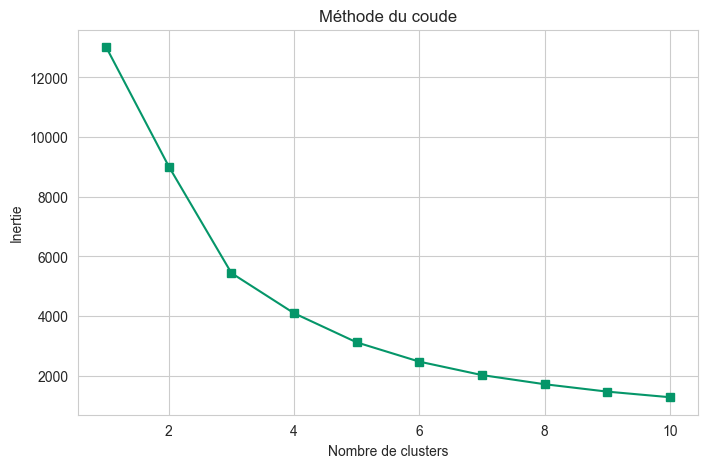

In [11]:
# Méthode du coude pour estimer le nombre de clusters
inerties = []
plage_k = range(1, 11)

for k in plage_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_norm)
    inerties.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(plage_k, inerties, marker="s", color="#059669")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.title("Méthode du coude")
plt.show()

In [12]:
# Confirmation avec le score de silhouette
scores_sil = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquettes = km.fit_predict(rfm_norm)
    scores_sil[k] = silhouette_score(rfm_norm, etiquettes)
scores_sil

{2: 0.8958249711727472,
 3: 0.5942233320872992,
 4: 0.6162275299061803,
 5: 0.6165002474679847,
 6: 0.5982885618366588}

Le score brut est maximal pour deux clusters, mais ce découpage isole seulement quelques clients extrêmes et n'a pas d'intérêt marketing. Un découpage en quatre clusters offre le meilleur équilibre entre qualité et exploitabilité, en accord avec la méthode du coude. On retient donc quatre segments.

In [13]:
# Modèle final K-Means à 4 clusters
modele_km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Segment"] = modele_km.fit_predict(rfm_norm)
rfm.head()

,Recency,Frequency,Monetary,Segment
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [14]:
# Profil moyen de chaque segment
profils = rfm.groupby("Segment").agg(
    Recency_moy=("Recency", "mean"),
    Frequency_moy=("Frequency", "mean"),
    Monetary_moy=("Monetary", "mean"),
    Effectif=("Segment", "count")
).round(1)
profils

,Recency_moy,Frequency_moy,Monetary_moy,Effectif
Segment,,,,
0,43.7,3.7,1353.6,3054
1,248.1,1.6,478.8,1067
2,7.4,82.5,127188.0,13
3,15.5,22.3,12690.5,204


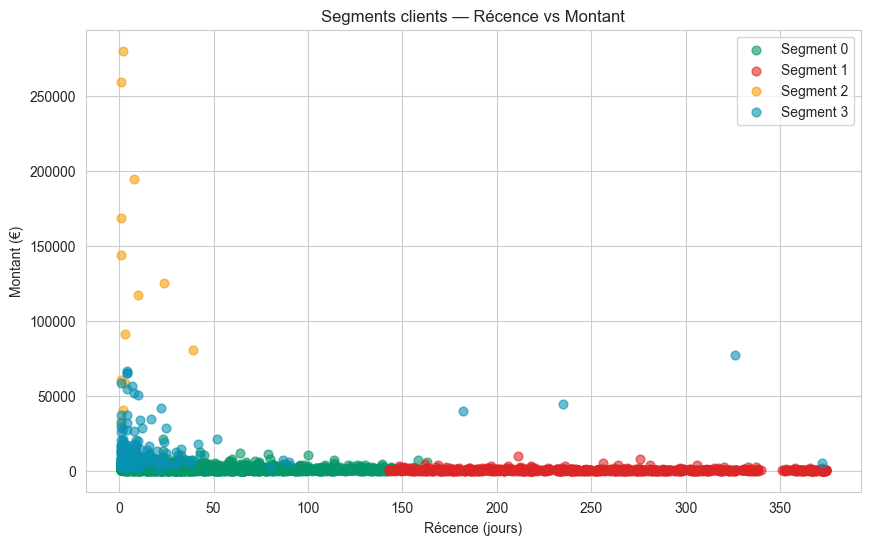

In [15]:
# Visualisation : Récence vs Montant
plt.figure(figsize=(10, 6))
palette = ["#059669", "#dc2626", "#f59e0b", "#0891b2"]

for seg in range(4):
    sous = rfm[rfm["Segment"] == seg]
    plt.scatter(sous["Recency"], sous["Monetary"],
                c=palette[seg], label=f"Segment {seg}", s=40, alpha=0.6)

plt.xlabel("Récence (jours)")
plt.ylabel("Montant (€)")
plt.title("Segments clients — Récence vs Montant")
plt.legend()
plt.show()

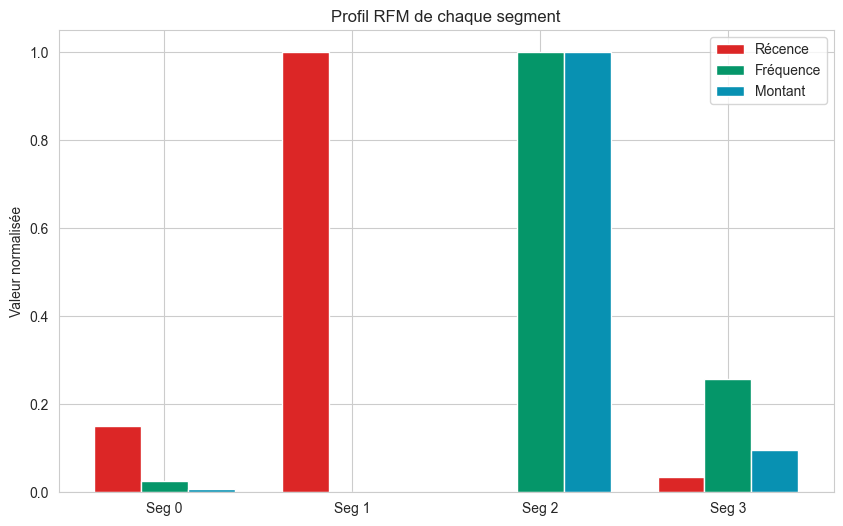

In [16]:
# Comparaison des profils normalisés (barres groupées)
profil_moy = rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean()
profil_mm = (profil_moy - profil_moy.min()) / (profil_moy.max() - profil_moy.min())

x = np.arange(4)
larg = 0.25
plt.figure(figsize=(10, 6))
plt.bar(x - larg, profil_mm["Recency"], larg, label="Récence", color="#dc2626")
plt.bar(x, profil_mm["Frequency"], larg, label="Fréquence", color="#059669")
plt.bar(x + larg, profil_mm["Monetary"], larg, label="Montant", color="#0891b2")
plt.xticks(x, [f"Seg {i}" for i in range(4)])
plt.ylabel("Valeur normalisée")
plt.title("Profil RFM de chaque segment")
plt.legend()
plt.show()

## Partie 5 — Interprétation métier

Les quatre segments correspondent à des profils clairs :

- **Clients réguliers** : la majorité, achats récents et occasionnels, montant modéré. Le socle de la clientèle.
- **Clients à risque** : pas d'achat depuis longtemps, faible fréquence et faible montant. À réactiver.
- **Clients VIP** : très peu nombreux mais énormément de commandes et de dépenses. Probablement des revendeurs.
- **Clients premium** : récents, fidèles, bon panier. Les meilleurs clients particuliers.

## Partie 6 — Sauvegarde pour l'application

In [17]:
import os
os.makedirs("model", exist_ok=True)

joblib.dump(modele_km, "model/modele_kmeans.pkl")
joblib.dump(normaliseur, "model/normaliseur.pkl")
rfm.to_csv("rfm_data.csv")

## Partie 7 — Amélioration : DBSCAN

DBSCAN ne demande pas de fixer le nombre de clusters et sait isoler les clients atypiques (étiquette -1).

In [18]:
# Application de DBSCAN sur les données normalisées
modele_db = DBSCAN(eps=0.5, min_samples=5)
rfm["Segment_DBSCAN"] = modele_db.fit_predict(rfm_norm)
rfm["Segment_DBSCAN"].value_counts()

Segment_DBSCAN
 0    4284
-1      54
Name: count, dtype: int64

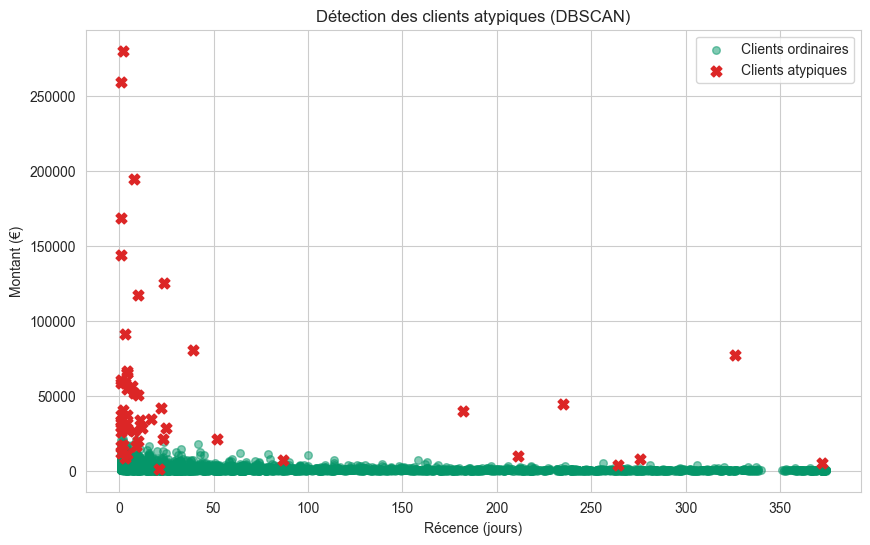

In [19]:
# Visualisation des clients atypiques repérés par DBSCAN
plt.figure(figsize=(10, 6))

ordinaires = rfm[rfm["Segment_DBSCAN"] != -1]
atypiques = rfm[rfm["Segment_DBSCAN"] == -1]

plt.scatter(ordinaires["Recency"], ordinaires["Monetary"],
            c="#059669", label="Clients ordinaires", s=30, alpha=0.5)
plt.scatter(atypiques["Recency"], atypiques["Monetary"],
            c="#dc2626", label="Clients atypiques", s=60, marker="X")

plt.xlabel("Récence (jours)")
plt.ylabel("Montant (€)")
plt.title("Détection des clients atypiques (DBSCAN)")
plt.legend()
plt.show()

DBSCAN regroupe la grande majorité des clients dans un seul ensemble dense et isole quelques dizaines de clients atypiques, correspondant aux très gros dépensiers. Il est donc complémentaire de K-Means : utile pour repérer les profils exceptionnels, mais moins adapté pour produire une segmentation marketing équilibrée. K-Means reste le meilleur choix pour la segmentation globale.